In [ ]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt

/var/folders/kj/mw8m0pb120bdckmf26htnw940000gn/T/ipykernel_72538/2149086895.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  solid_outline_geom = rooms_gdf.geometry.buffer(wall_bridge_distance).unary_union.buffer(-wall_bridge_distance)


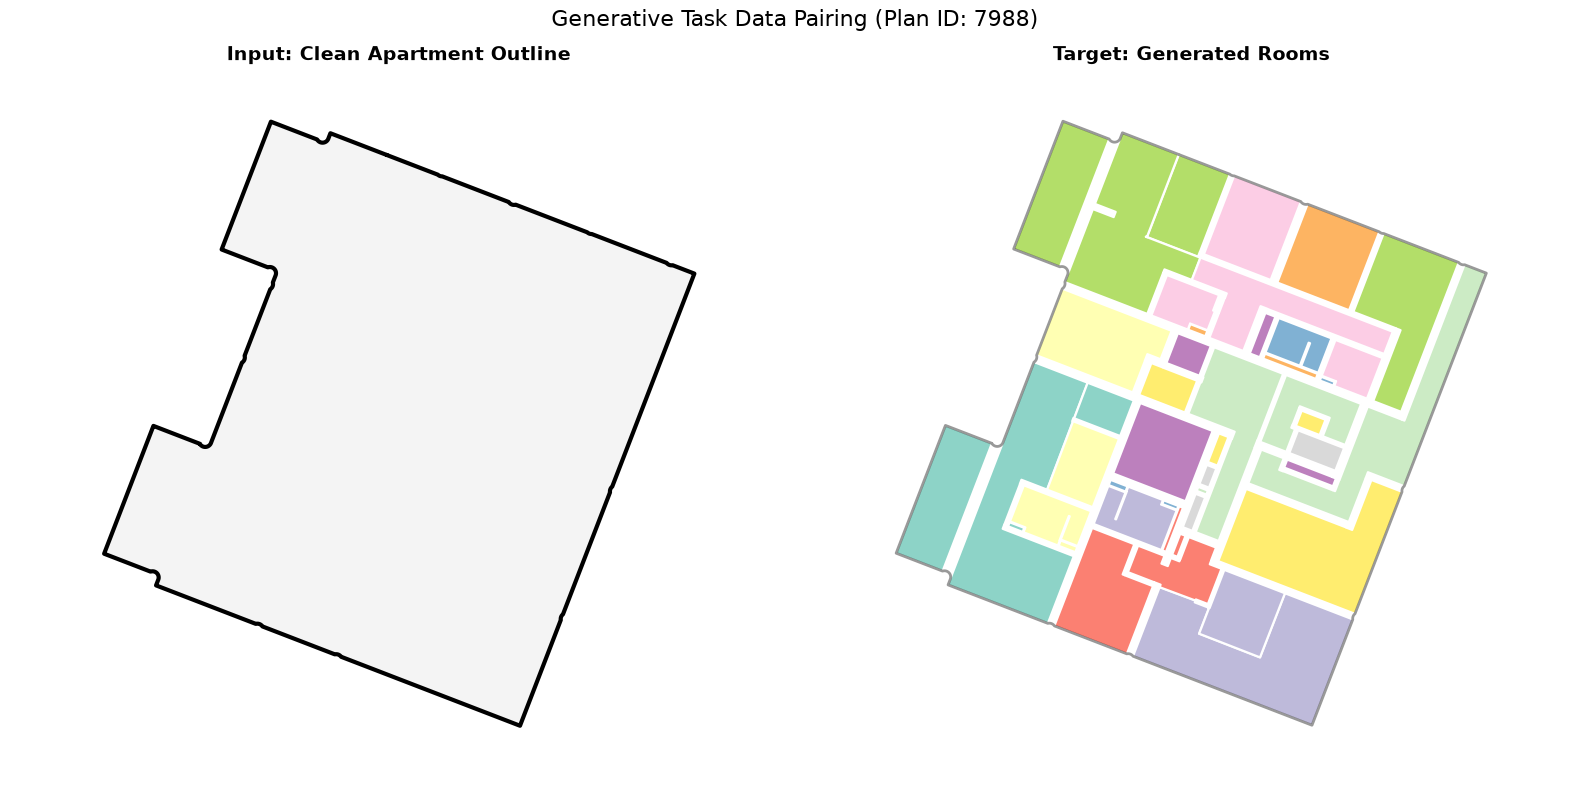

In [ ]:
# 1. Load data
csv_path = "mds_V2_5.372k.csv"
df = pd.read_csv(csv_path)
df['geom'] = df['geom'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(df, geometry='geom')
# 2. Isolate a plan
sample_plan_id = 7988
apartment_gdf = gdf[gdf['plan_id'] == sample_plan_id]
rooms_gdf = apartment_gdf[apartment_gdf['entity_type'] == 'area']
# Merge the rooms to create the outline
# 1. Buffer outward by 30 centimeters (MSD uses meters as units)
# 2. Cleanly unify them into one solid geometry
# 3. Buffer back inward by 30 centimeters to restore the original scale
wall_bridge_distance = 0.3
solid_outline_geom = rooms_gdf.geometry.buffer(wall_bridge_distance).unary_union.buffer(-wall_bridge_distance)
# Convert the resulting Shapely geometry back into a GeoDataFrame for plotting
outline_gdf = gpd.GeoDataFrame(geometry=[solid_outline_geom], crs=rooms_gdf.crs)
# -------------------------------------
# 3. Plot side-by-side again
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
# Left Plot: Condition
outline_gdf.plot(ax=ax1, facecolor='#f4f4f4', edgecolor='black', linewidth=3)
ax1.set_title("Input: Clean Apartment Outline", fontsize=14, fontweight='bold')
ax1.axis('equal')
ax1.axis('off')
# Right Plot: Target
rooms_gdf.plot(ax=ax2, cmap='Set3', edgecolor='white', linewidth=1.5)
outline_gdf.plot(ax=ax2, facecolor='none', edgecolor='black', linewidth=2, alpha=0.4)
ax2.set_title("Target: Generated Rooms", fontsize=14, fontweight='bold')
ax2.axis('equal')
ax2.axis('off')
plt.suptitle(f"Generative Task Data Pairing (Plan ID: {sample_plan_id})", fontsize=16)
plt.tight_layout()
plt.show()

In [3]:
df.head()

,Unnamed: 0.1,Unnamed: 0,apartment_id,site_id,building_id,plan_id,floor_id,unit_id,area_id,unit_usage,entity_type,entity_subtype,geom,elevation,height,zoning,roomtype
0,0,0,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619311.0,RESIDENTIAL,area,BATHROOM,POLYGON ((-2.733784407826521 4.079807440832154...,0.0,2.6,Zone3,Bathroom
1,1,1,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619303.0,RESIDENTIAL,area,LIVING_ROOM,"POLYGON ((5.827898870188732 7.816876723402972,...",0.0,2.6,Zone2,Livingroom
2,2,2,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619322.0,RESIDENTIAL,area,ROOM,"POLYGON ((6.755710720519119 2.413369594812586,...",0.0,2.6,Zone1,Bedroom
3,3,3,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619310.0,RESIDENTIAL,area,KITCHEN,POLYGON ((3.5821200013910017 5.140461688341118...,0.0,2.6,Zone2,Kitchen
4,4,4,3c3b1d6ca8b4b9092480b8c75f9eaa81,210,399,1054,1588,7300.0,619312.0,RESIDENTIAL,area,ROOM,"POLYGON ((3.014138045548928 4.182056855151666,...",0.0,2.6,Zone1,Bedroom
